In [1]:
!pip -q install datasets transformers evaluate accelerate sentence-transformers faiss-cpu scikit-learn pandas numpy matplotlib seaborn plotly umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.3 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import random
import torch
import faiss
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from datasets import load_dataset, Dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    pipeline
)

from sentence_transformers import SentenceTransformer, CrossEncoder

warnings.filterwarnings('ignore')

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1. Configuration

In [12]:
ENGLISH_ONLY = True
TEXT_MAX_LEN = 256
TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "Tobi-Bueck/customer-support-tickets"
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RERANKER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

OUTPUT_DIR = "artifacts_supportmind"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load dataset

In [5]:
raw_data = load_dataset(DATASET_NAME)
raw_data

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})

In [6]:
df = raw_data["train"].to_pandas()
print(df.shape)

(61765, 16)


In [7]:
df.head(1)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None


## 3. Inspect schema and map important columns

In [8]:
def find_col(columns, candidates):
    lowered = {c.lower(): c for c in columns}
    for cand in candidates:
        for c in columns:
            if c.lower() == cand.lower():
                return c
        
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

all_cols = list(df.columns)

In [9]:
subject_col = find_col(all_cols, ["subject"])
body_col = find_col(all_cols, ["body", "text", "email body"])
queue_col = find_col(all_cols, ["queue", "department"])
priority_col = find_col(all_cols, ["priority"])
language_col = find_col(all_cols, ["language", "lang"])
answer_col = find_col(all_cols, ["answer", "response", "reply"])
type_col = find_col(all_cols, ["type"])
business_type_col = find_col(all_cols, ["business type", "business_type"])

In [10]:
tag_cols = [c for c in all_cols if "tag" in c.lower()]
column_map = {
    "subject_col": subject_col,
    "body_col": body_col,
    "queue_col": queue_col,
    "priority_col": priority_col,
    "language_col": language_col,
    "answer_col": answer_col,
    "type_col": type_col,
    "business_type_col": business_type_col,
    "tag_cols": tag_cols,
}

column_map

{'subject_col': 'subject',
 'body_col': 'body',
 'queue_col': 'queue',
 'priority_col': 'priority',
 'language_col': 'language',
 'answer_col': 'answer',
 'type_col': 'type',
 'business_type_col': None,
 'tag_cols': ['tag_1',
  'tag_2',
  'tag_3',
  'tag_4',
  'tag_5',
  'tag_6',
  'tag_7',
  'tag_8']}

In [11]:
required = [subject_col, body_col, queue_col, priority_col, language_col, answer_col]

missing = [c for c in required if c is None]
if missing:
    raise ValueError(f"columns were not found")

## 4. Basic cleaning and feature creation

In [13]:
work_df = df.copy()

for col in [subject_col, body_col, queue_col, priority_col, language_col, answer_col]:
    work_df[col] = work_df[col].astype(str).fillna("")

work_df["text"] = (
    work_df[subject_col].fillna("").astype(str).str.strip() + "\n\n" + work_df[body_col].fillna("").astype(str).str.strip()
)

In [14]:
work_df["text"] = work_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

work_df["answer_col"] = work_df[answer_col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()


work_df = work_df[work_df["text"].str.len() > 20].copy()
work_df = work_df[work_df[queue_col].str.len() > 0].copy()
work_df = work_df[work_df["answer_col"].str.len() > 0].copy()

In [16]:
if ENGLISH_ONLY:
    work_df = work_df[work_df[language_col].str.lower().isin(["en", "english"])].copy()

work_df = work_df.reset_index(drop=True)


print(work_df.shape)
work_df[[subject_col, body_col, queue_col, priority_col, language_col, answer_col]].head(2)

(28259, 18)


,subject,body,queue,priority,language,answer
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,en,"Thank you for reaching out, <name>. We are awa..."
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,en,Thank you for your inquiry. Our products suppo...


## 5. EDA

In [17]:
print("Unique queues:", work_df[queue_col].nunique())
print("Unique priorities:", work_df[priority_col].nunique())
print("Languages:", work_df[language_col].value_counts().to_dict())

display(work_df[[queue_col, priority_col]].describe(include='object'))

Unique queues: 10
Unique priorities: 3
Languages: {'en': 28259}


,queue,priority
count,28259,28259
unique,10,3
top,Technical Support,medium
freq,8149,11568


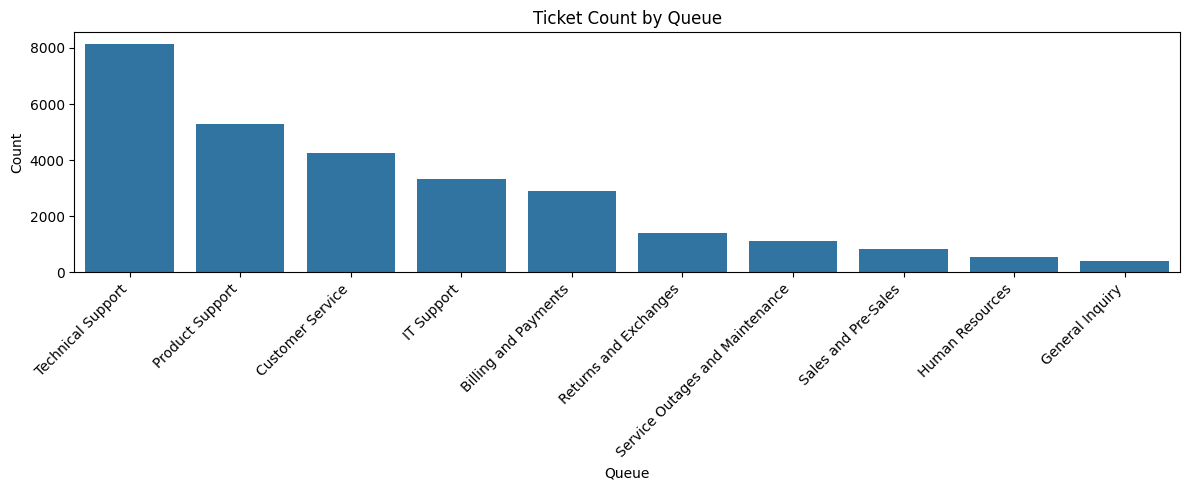

In [18]:
queue_counts = work_df[queue_col].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=queue_counts.index, y=queue_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Ticket Count by Queue")
plt.xlabel("Queue")
plt.ylabel("Count")
plt.tight_layout()
plt.show()